In [1]:
import sqlite3
import pandas as pd

# connect to DB (correct path)
conn = sqlite3.connect("../database/superstore.db")

# load cleaned CSV
df = pd.read_csv("../data/cleaned_superstore.csv")

# push data into SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# VERIFY TABLE EXISTS
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn))

# preview data
print(pd.read_sql("SELECT * FROM superstore LIMIT 5;", conn))

         name
0  superstore
   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_superstore.csv")
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125


## Descriptive Statistics

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order_Date     9994 non-null   object 
 3   Ship_Date      9994 non-null   object 
 4   Ship_Mode      9994 non-null   object 
 5   Customer_ID    9994 non-null   object 
 6   Customer_Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal_Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product_ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.describe()


,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Year,Month,Profit_Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,0.120314
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,0.466754
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-2.750000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,0.075000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,0.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,0.362500
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,0.500000


In [5]:
df.describe(include='object')

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub-Category,Product_Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,2016-09-05,2015-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


### Observations made:
##### The dataset contains sales, profit, discount, quantity, customer, product, and regional information.
##### Numerical columns help analyze business performance, while categorical columns help compare categories, regions, and segments.
##### The dataset is suitable for sales and profitability analysis.

In [6]:
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


### Observation made:
##### Sales and profit vary widely across orders.
##### Discount values are limited to a few levels, which makes it useful for studying discount impact.
##### Quantity values are smaller compared to sales, showing that revenue depends not only on quantity but also on product value.

## Univariate Analysis

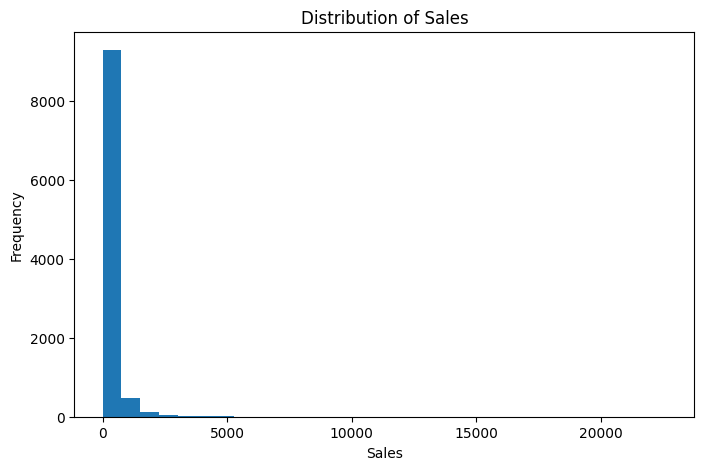

In [7]:
# Histogram of Sales
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Insights:
##### The sales distribution is highly right-skewed, indicating that most transactions involve low to moderate sales, while a small number of high-value orders contribute significantly to overall revenue.

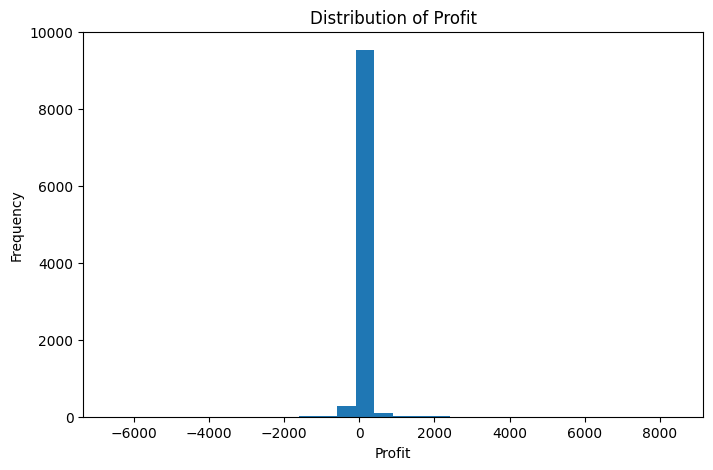

In [8]:
#Histogram of profit

plt.figure(figsize=(8,5))
plt.hist(df['Profit'], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

### Insights
##### The profit distribution shows that most transactions yield low profit margins, with a noticeable presence of loss-making orders. This suggests that the business is not consistently profitable across all transactions, likely due to factors such as high discounts or operational costs.

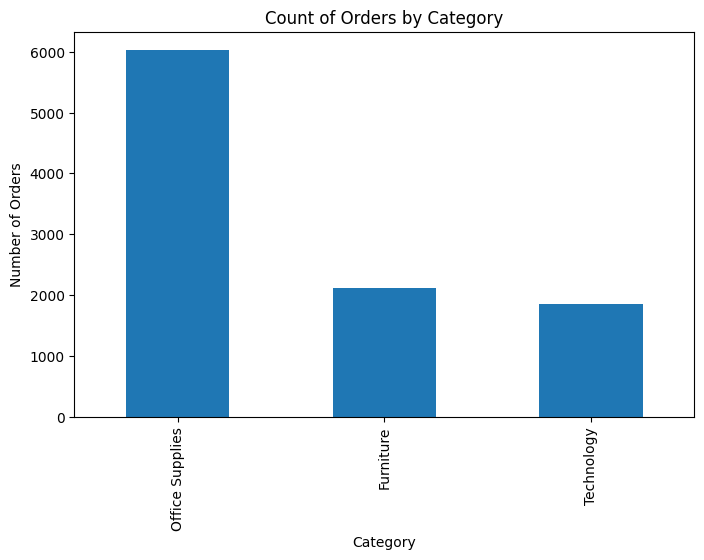

In [9]:
#Bar chart of Category counts

plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Count of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

### Insights
#### Office Supplies has the highest number of orders, followed by Furniture and Technology. This suggests that Office Supplies products are in higher demand, although high order volume does not necessarily indicate higher profitability.

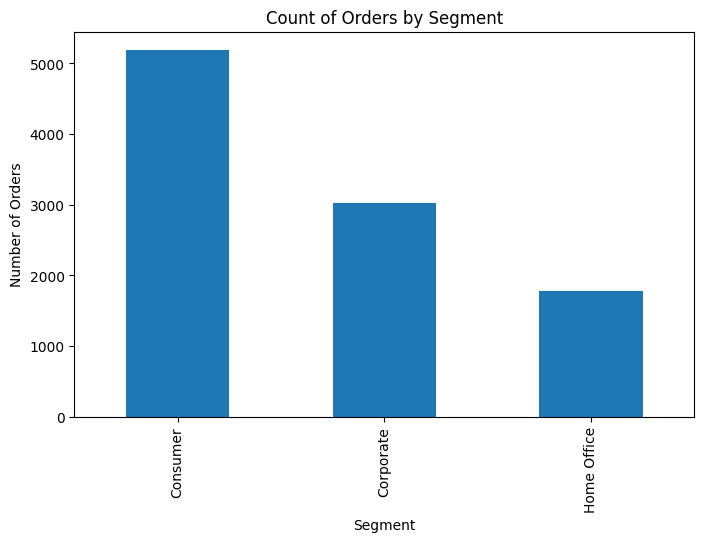

In [10]:
# bar chart of segment counts

plt.figure(figsize=(8,5))
df['Segment'].value_counts().plot(kind='bar')
plt.title("Count of Orders by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")
plt.show()

### Insights
##### The Consumer segment accounts for the highest number of orders, followed by Corporate and Home Office. This shows that individual customers form the largest portion of the customer base.

## Bivariate analysis

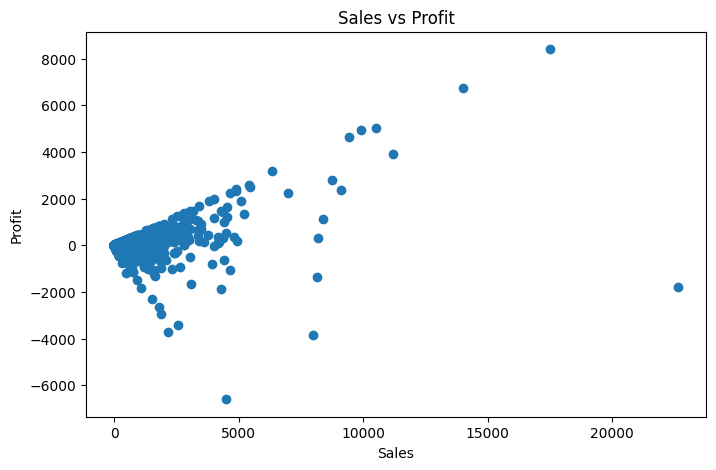

In [11]:
#sales vs profit Scatter plot

plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

### Insights

##### The scatter plot shows a moderate positive relationship between sales and profit; however, several high-sales transactions result in low or negative profit. This indicates that increased sales do not always guarantee profitability, likely due to high discounts or costs.

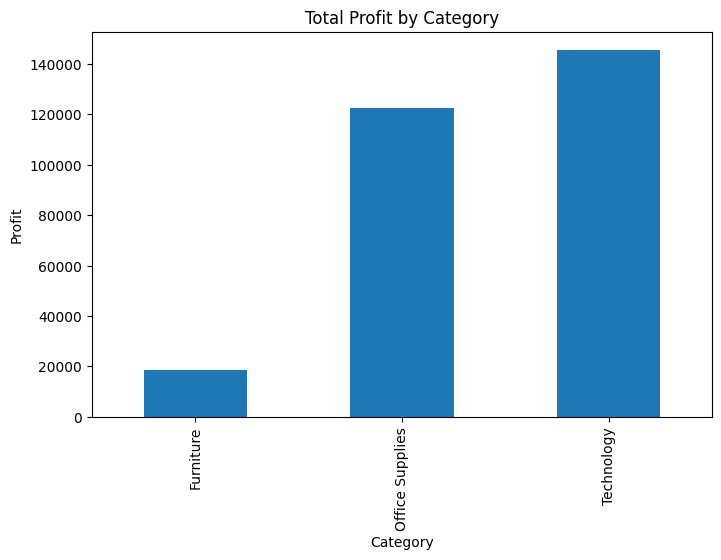

In [12]:
# category vs Profit

plt.figure(figsize=(8,5))
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

### Insights

##### Technology generates the highest total profit, followed by Office Supplies, while Furniture contributes the least profit. This suggests that Technology products are more profitable, whereas Furniture may have lower margins or higher costs.

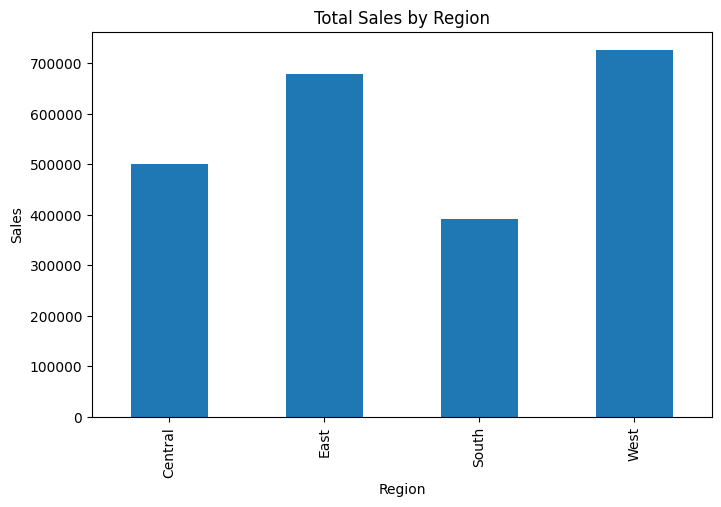

In [13]:
#Region vs Sales

plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

### Insights

##### The West region records the highest sales, followed by the East, Central, and South regions. This indicates stronger market performance in the West region compared to others.

## Multivariate analysis

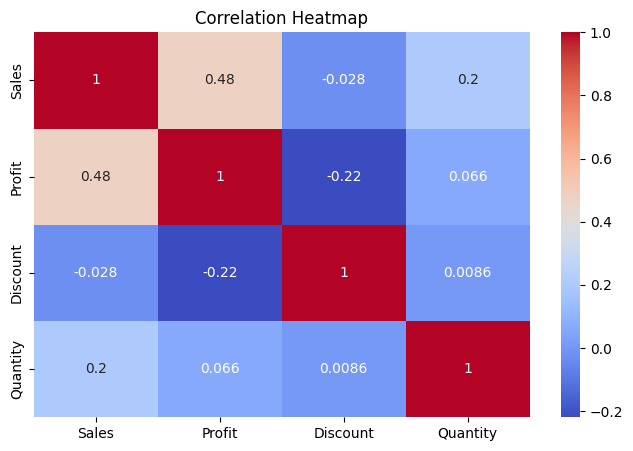

In [14]:
# Correlation Heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales', 'Profit', 'Discount', 'Quantity']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insights

##### The heatmap shows a moderate positive correlation between sales and profit, while discount has a negative correlation with profit. This suggests that higher discounts tend to reduce profitability, highlighting the need for optimized discount strategies.

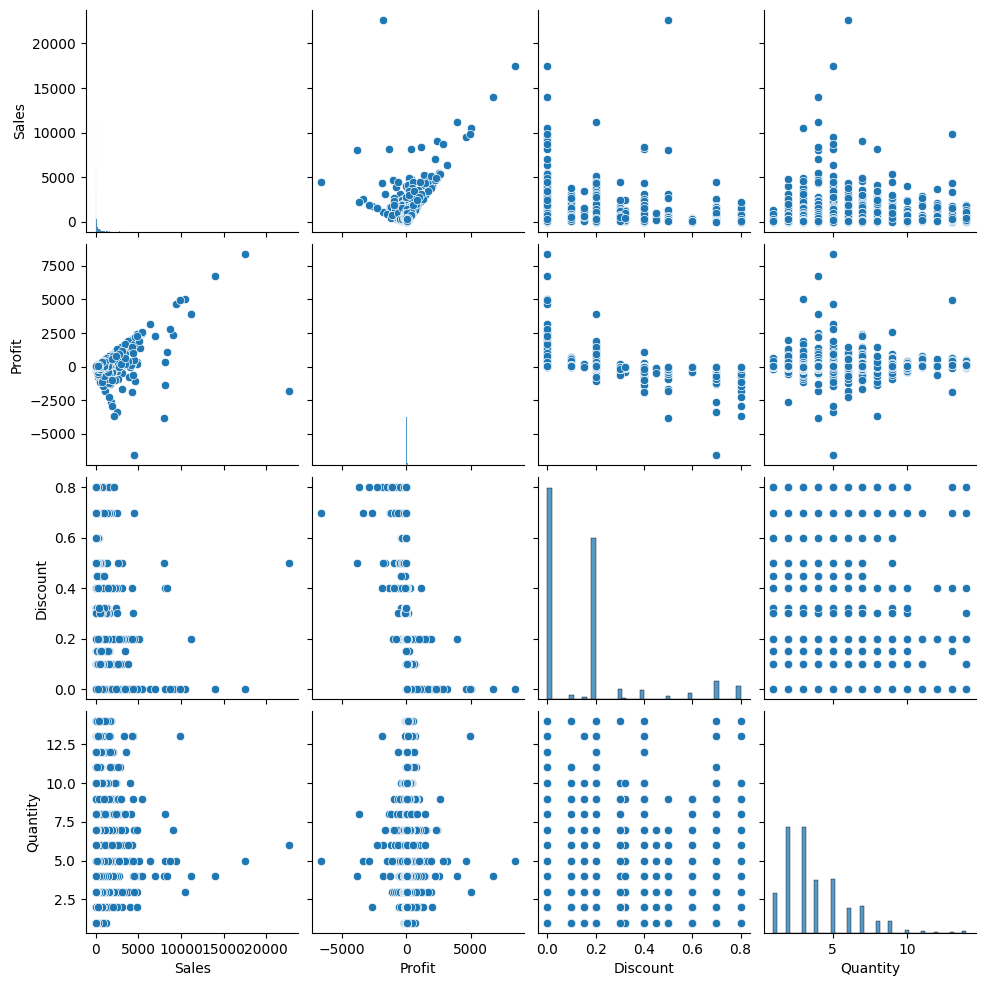

In [15]:
#PairPlot

sns.pairplot(df[['Sales', 'Profit', 'Discount', 'Quantity']])
plt.show()

### Insights

##### The pair plot reveals relationships among numerical variables, showing that higher discounts are often associated with lower profits. It also highlights the presence of outliers and variability in sales and profit values.

## Time-based Analysis

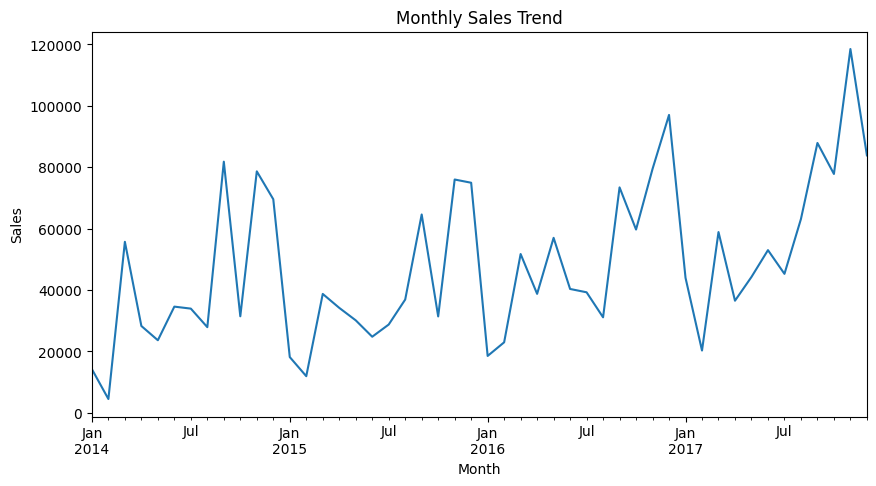

In [16]:
#monthly sales trend

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Insights 

##### The monthly sales trend shows fluctuations over time, with noticeable peaks and dips. This indicates possible seasonality in sales, which can help businesses plan inventory and promotional strategies.


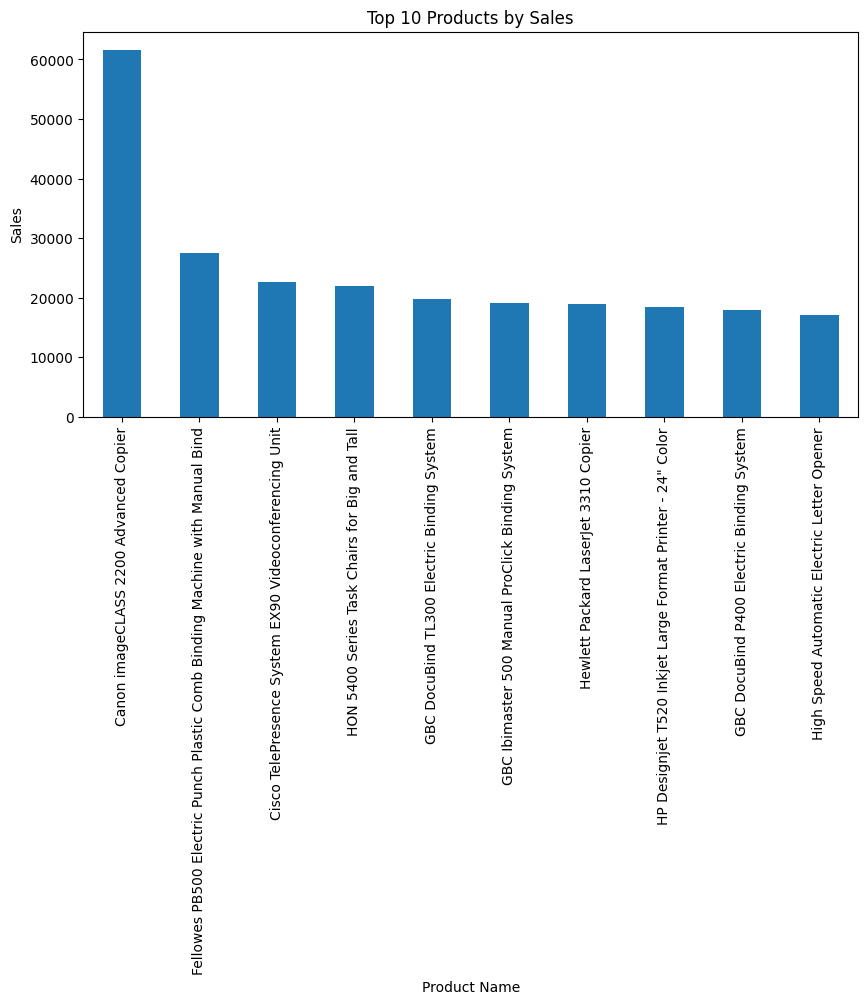

In [17]:
#Top products analysis

top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.show()

### Insights

##### A small number of products contribute significantly to total sales, with the top product generating substantially higher revenue than others. This highlights product concentration and the importance of focusing on high-performing products.

## Final Key Insights

##### Sales are highly skewed, with a small number of high-value transactions driving most revenue.
##### Profitability is inconsistent, with several transactions resulting in losses.
##### Discounts negatively impact profit, indicating the need for better pricing strategies.
##### Technology is the most profitable category, while Furniture underperforms in profit.
##### The West region leads in sales, showing strong regional performance.
##### Consumer segment dominates in terms of order volume.
##### Monthly sales show fluctuations, suggesting seasonal trends.
##### A few top products contribute heavily to total revenue, indicating product concentration.

In [ ]:
# KPI calculations

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
avg_discount = df['Discount'].mean()


top_region = df.groupby('Region')['Sales'].sum().idxmax()
top_category = df.groupby('Category')['Profit'].sum().idxmax()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Discount:", avg_discount)
print("Top Region:", top_region)
print("Top Category:", top_category)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Average Discount: 0.15620272163297977
Top Region: West
Top Category: Technology
